<a href="https://colab.research.google.com/github/imnishu07/TensorFlow_Lite_Projects/blob/Thesis-Projects/LinearToMultiStepConvOptimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is an extension to 001TSF file and it focuses on optimizing models from linear to multi-step conv using Pruning and Quantization

In [ ]:
'''
Setup: In essence, this cell is preparing the notebook with the tools,
We need for data handling, analysis, visualization, and potentially building machine learning models.
'''

import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [ ]:
!pip install tf_keras tensorflow-model-optimization --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasteri

In [ ]:
import tf_keras        # drop-in replacement
import tensorflow_model_optimization as tfmot

In [ ]:
'''
This dataset contains 14 different features such as air temperature, atmospheric pressure, and humidity.
These were collected every 10 minutes, beginning in 2003
For efficiency, we will use only the data collected between 2009 and 2016.
'''

zip_path = tf_keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 [==============================] - 0s 0us/step


In [ ]:
df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


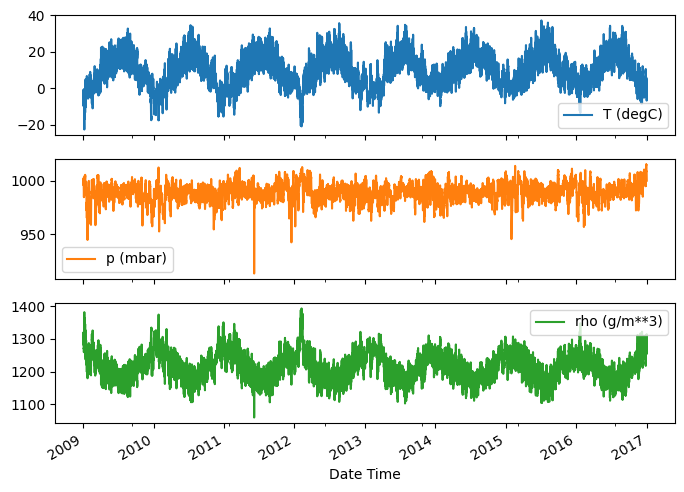

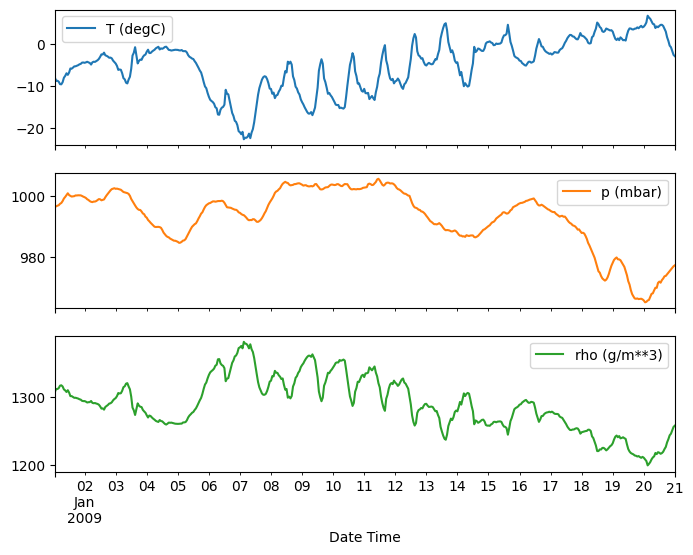

In [ ]:
#Here is the evolution of few features over time

plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

In [ ]:
#Inspect and cleanup
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


In [ ]:
#There's a separate wind direction column, so the velocity should be greater than zero. Replace it with zeros

wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

# The above inplace edits are reflected in the DataFrame.
df['wv (m/s)'].min()

0.0

(np.float64(-11.305513973134667),
 np.float64(8.24469928549079),
 np.float64(-8.27438540335515),
 np.float64(7.7338312955467785))

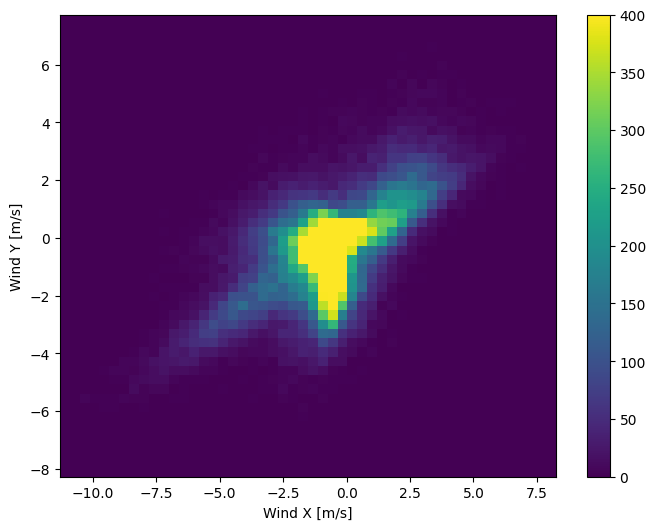

In [ ]:
#Let's convert the wind direction and velocity columns to a wind vector

wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

plt.hist2d(df['Wx'], df['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

Text(0.5, 1.0, 'Time of day signal')

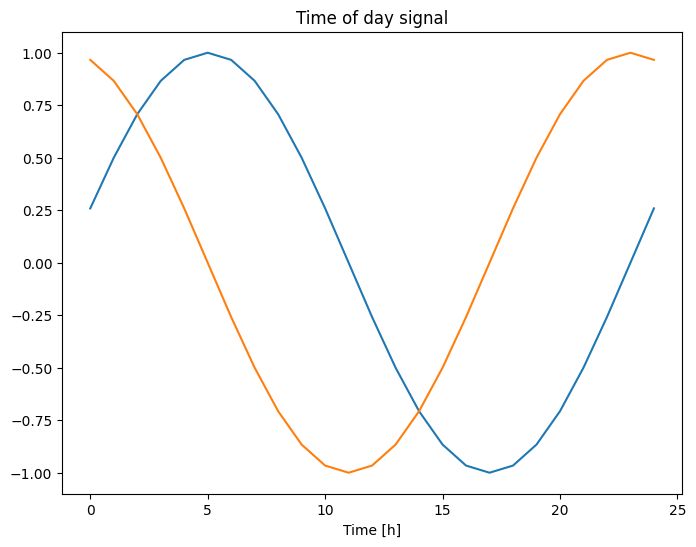

In [ ]:
#Similarly, converting the Date Time column to seconds
timestamp_s = date_time.map(pd.Timestamp.timestamp)

#Similarly, to deal with periodicity, we can get usable signals using sine and cosine transforms

day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

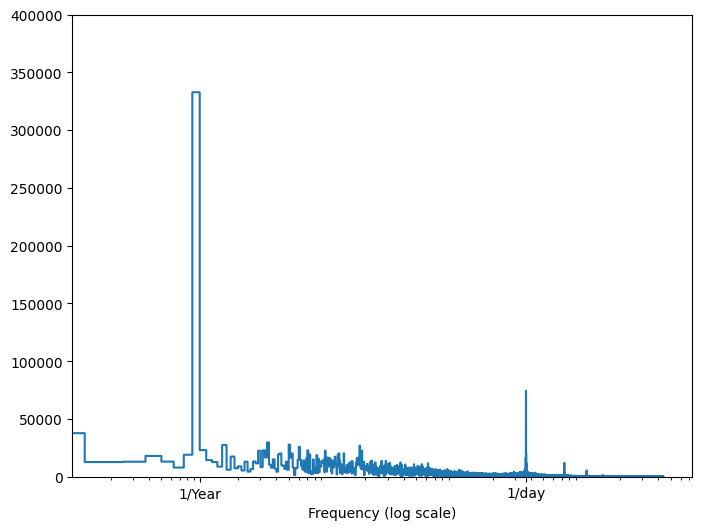

In [ ]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

In [ ]:
#Split the data

column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

In [ ]:
#Normalize the data

train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

/tmp/ipykernel_2033/3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


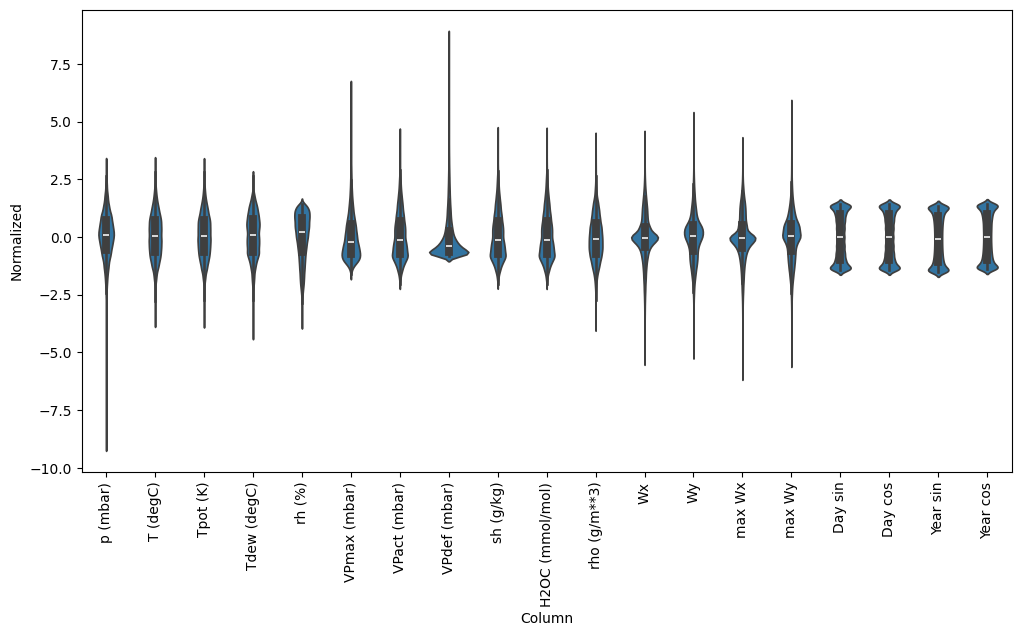

In [ ]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

In [ ]:
#Data Windowing

class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [ ]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['T (degC)'])
w1

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']

In [ ]:
w2 = WindowGenerator(input_width=6,
                     label_width=1,
                     shift=1,
                     label_columns=['T (degC)'])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

In [ ]:
#Split: Split_window method will convert them to a window of inputs and a window of labels

def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


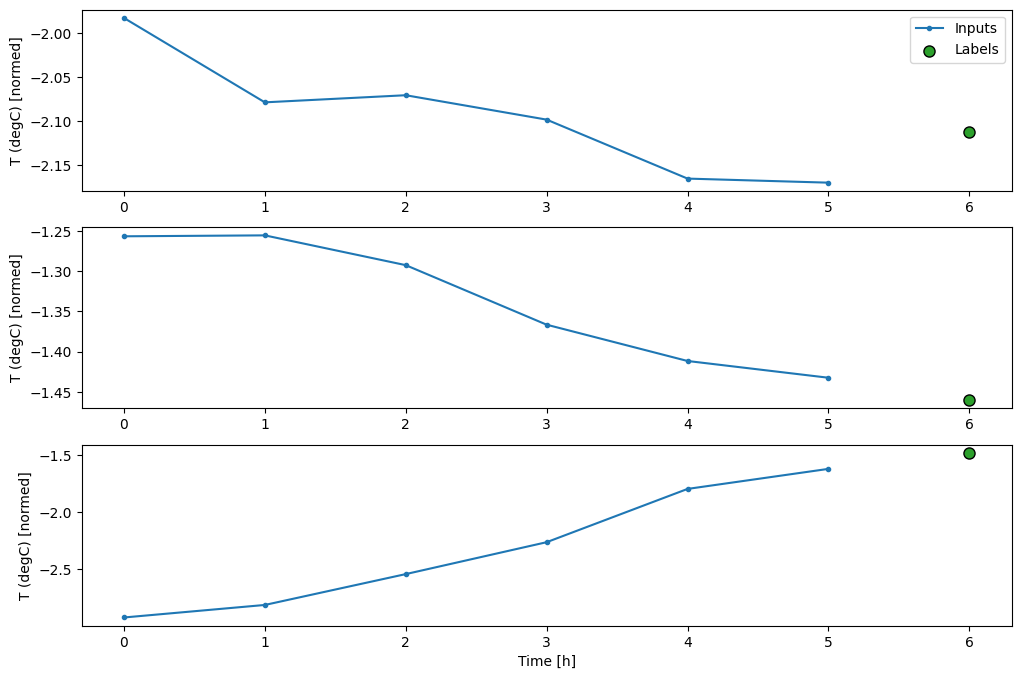

In [ ]:
#Plot: plot_method allows a simple visualization of the split window:

w2.example = example_inputs, example_labels

def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

w2.plot()

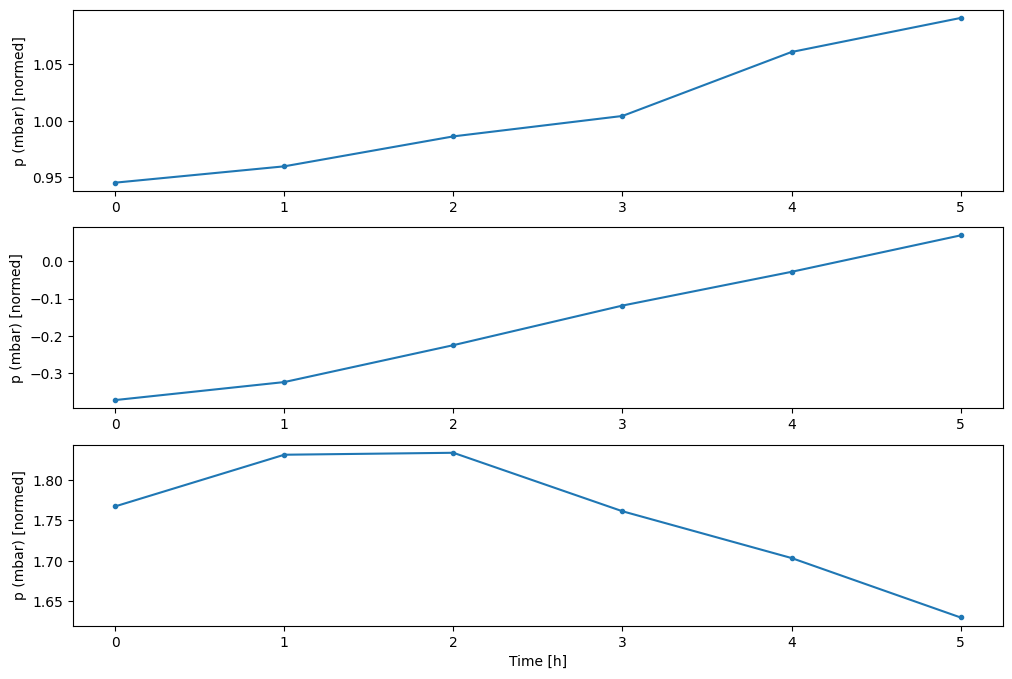

In [ ]:
#Similarly for other features

w2.plot(plot_col='p (mbar)')

In [ ]:
#Create tf.data.Datasets

def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf_keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [ ]:
#Since, the WindowGenerator object holds training, validation, and test data.
#Therefore, add properties for accessing and plotting them.

@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [ ]:
#Each element is an (inputs, label) pair
w2.train.element_spec

(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [ ]:
#Iterating over a Dataset yields concrete batches

for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


In [ ]:
#Start by building models to predict the T(degC) value one hour into the future

#Configure a WG object to produce these single-step pairs
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['T (degC)'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

In [ ]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 19)
Labels shape (batch, time, features): (32, 1, 1)


In [ ]:
#Creating a performance baseline as a point of comparison with the later more complicated models

class Baseline(tf_keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

baseline = Baseline(label_index=column_indices['T (degC)'])

baseline.compile(loss=tf_keras.losses.MeanSquaredError(),
                 metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

439/439 [==============================] - 6s 11ms/step - loss: 0.0128 - mean_absolute_error: 0.0785


In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['T (degC)'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


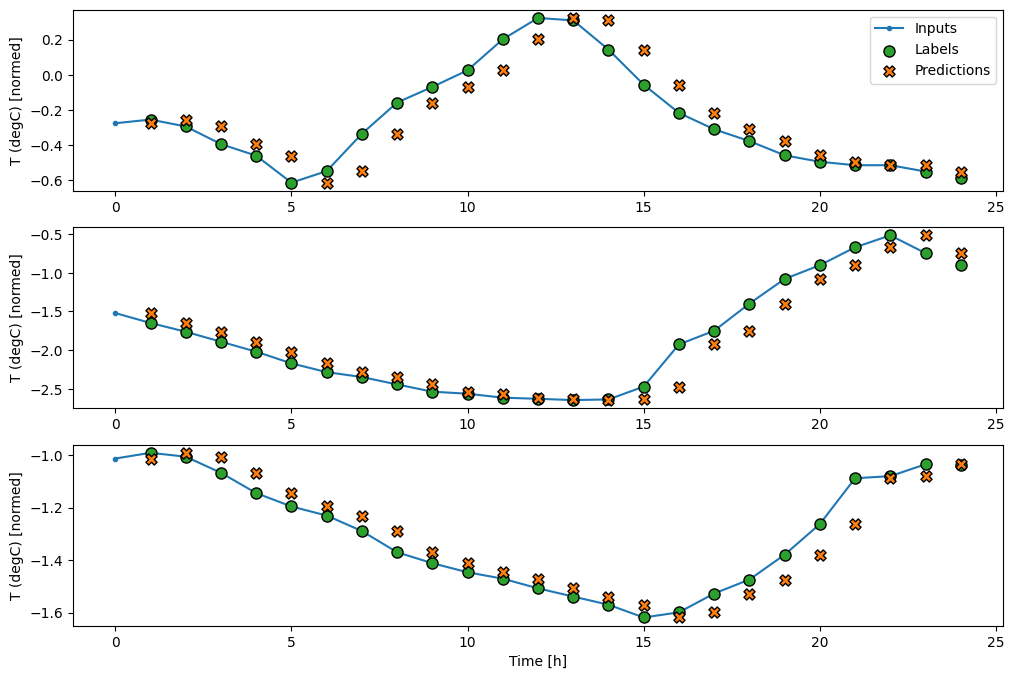

In [ ]:
wide_window.plot(baseline)

In [ ]:
#Training a basic and most simple linear model

linear = tf_keras.Sequential([
    tf_keras.layers.Dense(units=1)
])

print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

Input shape: (32, 1, 19)
Output shape: (32, 1, 1)


In [ ]:
#We will be training many models, therefore let's package the training procedure into a function:

MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2, callbacks=None):
  early_stopping = tf_keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  if callbacks is None:
      callbacks = []
  callbacks.append(early_stopping)

  model.compile(loss=tf_keras.losses.MeanSquaredError(),
                optimizer=tf_keras.optimizers.Adam(),
                metrics=[tf_keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=callbacks)
  return history

In [ ]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 [==============================] - 11s 6ms/step - loss: 0.1557 - mean_absolute_error: 0.2260 - val_loss: 0.0092 - val_mean_absolute_error: 0.0708
Epoch 2/20
1534/1534 [==============================] - 9s 6ms/step - loss: 0.0091 - mean_absolute_error: 0.0696 - val_loss: 0.0086 - val_mean_absolute_error: 0.0682
Epoch 3/20
1534/1534 [==============================] - 8s 5ms/step - loss: 0.0090 - mean_absolute_error: 0.0693 - val_loss: 0.0086 - val_mean_absolute_error: 0.0682
Epoch 4/20
439/439 [==============================] - 2s 4ms/step - loss: 0.0087 - mean_absolute_error: 0.0686


In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', linear(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


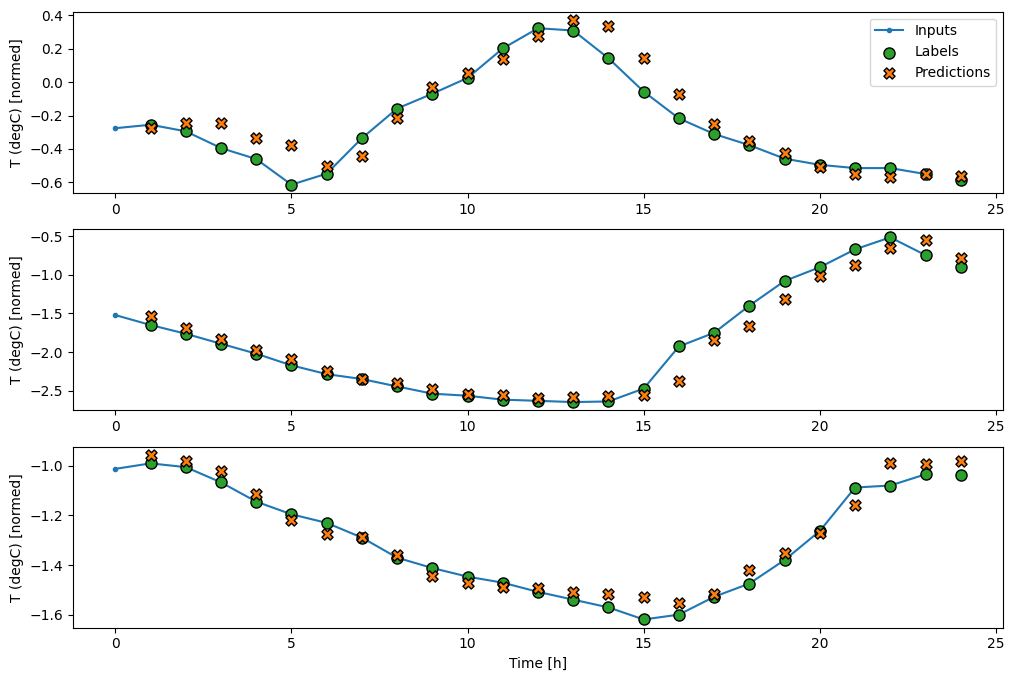

In [ ]:
wide_window.plot(linear)

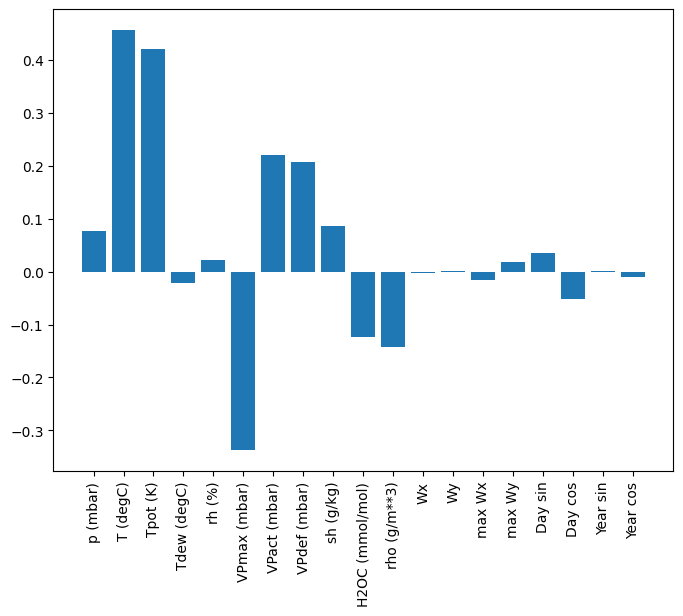

In [ ]:
#One advantage of linear models is that they're relatively simple to interpret.

plt.bar(x = range(len(train_df.columns)),
        height=linear.layers[0].kernel[:,0].numpy())
axis = plt.gca()
axis.set_xticks(range(len(train_df.columns)))
_ = axis.set_xticklabels(train_df.columns, rotation=90)

In [ ]:
#Let's make our model a little more dense to achieve better results

dense = tf_keras.Sequential([
    tf_keras.layers.Dense(units=64, activation='relu'),
    tf_keras.layers.Dense(units=64, activation='relu'),
    tf_keras.layers.Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 [==============================] - 11s 7ms/step - loss: 0.0143 - mean_absolute_error: 0.0772 - val_loss: 0.0080 - val_mean_absolute_error: 0.0659
Epoch 2/20
1534/1534 [==============================] - 11s 7ms/step - loss: 0.0077 - mean_absolute_error: 0.0634 - val_loss: 0.0081 - val_mean_absolute_error: 0.0660
Epoch 3/20
1534/1534 [==============================] - 9s 6ms/step - loss: 0.0074 - mean_absolute_error: 0.0617 - val_loss: 0.0068 - val_mean_absolute_error: 0.0591
Epoch 4/20
1534/1534 [==============================] - 10s 6ms/step - loss: 0.0072 - mean_absolute_error: 0.0607 - val_loss: 0.0070 - val_mean_absolute_error: 0.0603
Epoch 5/20
439/439 [==============================] - 2s 4ms/step - loss: 0.0068 - mean_absolute_error: 0.0586


In [ ]:
#Multi-step dense
'''
A single-time-step model has no context for the current values of its inputs. It can't see how the input features are changing over time.
To address this issue, the model needs access to multiple time steps when making prediction:
'''

CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['T (degC)'])

conv_window

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['T (degC)']

Text(0.5, 0.98, 'Given 3 hours of inputs, predict 1 hour into the future.')

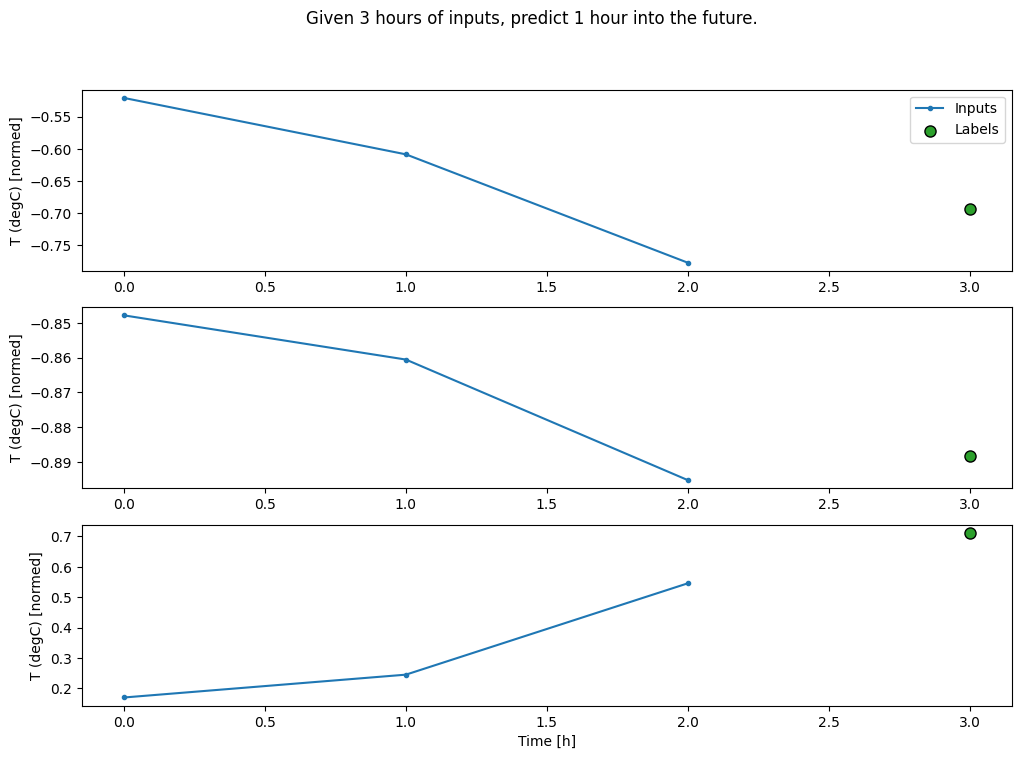

In [ ]:
conv_window.plot()
plt.suptitle("Given 3 hours of inputs, predict 1 hour into the future.")

In [ ]:
multi_step_dense = tf_keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf_keras.layers.Flatten(input_shape=(CONV_WIDTH, num_features)),
    tf_keras.layers.Dense(units=32, activation='relu'),
    tf_keras.layers.Dense(units=32, activation='relu'),
    tf_keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf_keras.layers.Reshape([1, -1]),
])

print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(multi_step_dense, conv_window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

438/438 [==============================] - 2s 4ms/step - loss: 0.0068 - mean_absolute_error: 0.0573


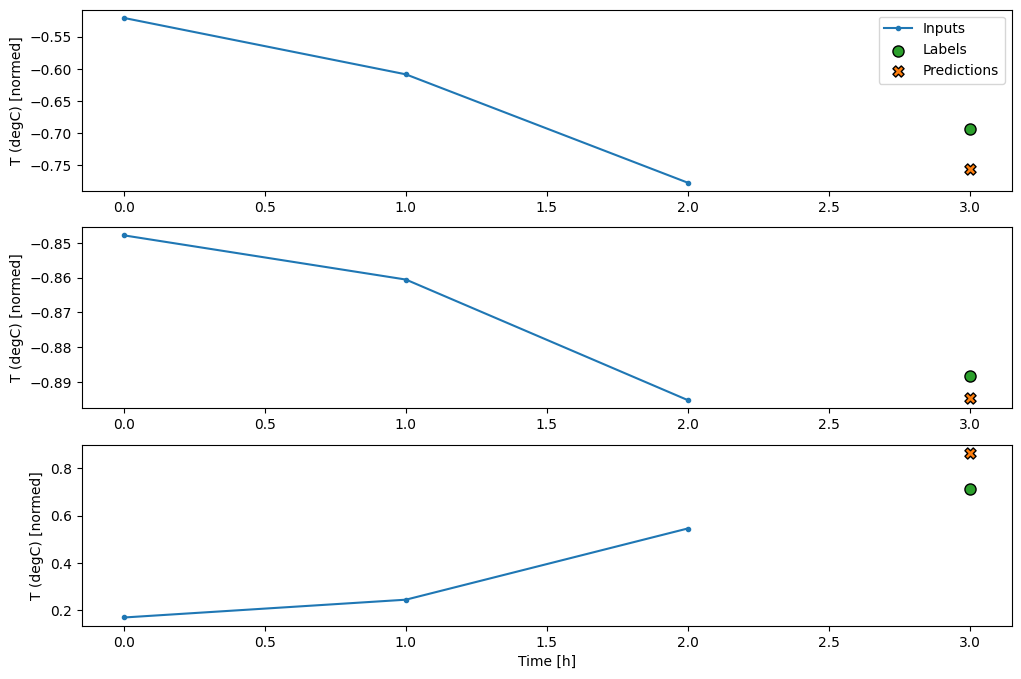

In [ ]:
conv_window.plot(multi_step_dense)

In [ ]:
#The main down-side of this approach is that the resulting model can only be executed on input windows of exactly this shape

print('Input shape:', wide_window.example[0].shape)
try:
  print('Output shape:', multi_step_dense(wide_window.example[0]).shape)
except Exception as e:
  print(f'\n{type(e).__name__}:{e}')

Input shape: (32, 24, 19)

ValueError:Exception encountered when calling layer 'sequential_2' (type Sequential).

Input 0 of layer "dense_4" is incompatible with the layer: expected axis -1 of input shape to have value 57, but received input with shape (32, 456)

Call arguments received by layer 'sequential_2' (type Sequential):
  • inputs=tf.Tensor(shape=(32, 24, 19), dtype=float32)
  • training=None
  • mask=None


Therefore, CNN fixes this problem.

In [ ]:
conv_model = tf_keras.Sequential([
    tf_keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf_keras.layers.Dense(units=32, activation='relu'),
    tf_keras.layers.Dense(units=1),
])

In [ ]:
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

Conv model on `conv_window`
Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(conv_model, conv_window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

438/438 [==============================] - 2s 4ms/step - loss: 0.0061 - mean_absolute_error: 0.0544


The difference between this conv_model and the multi-step dense model is that the conv_model can be run on inputs of any length.

In [ ]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 22, 1)


In [ ]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['T (degC)'])

wide_conv_window

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['T (degC)']

In [ ]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Wide conv window
Input shape: (32, 26, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


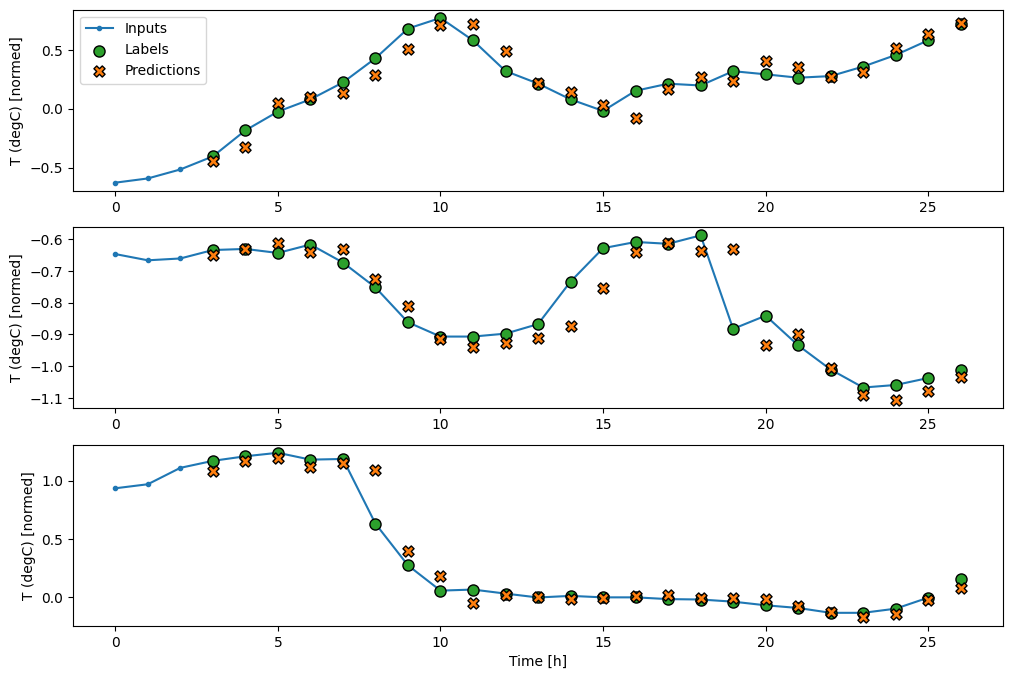

In [ ]:
wide_conv_window.plot(conv_model)

In [ ]:
multi_step_conv_model = tf_keras.Sequential([
    # Shape [batch, time, features] => [batch, time, filters]
    tf_keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf_keras.layers.Dense(units=32, activation='relu'),
    tf_keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf_keras.layers.Reshape([1, -1]),
])

print("Multi-step Conv model on `w2`")
print('Input shape:', w2.example[0].shape)
print('Output shape:', multi_step_conv_model(w2.example[0]).shape)

Multi-step Conv model on `w2`
Input shape: (32, 6, 19)
Output shape: (32, 1, 4)


In [ ]:
history = compile_and_fit(multi_step_conv_model, w2)

IPython.display.clear_output()
val_performance['Multi-step Conv'] = multi_step_conv_model.evaluate(w2.val, return_dict=True)
performance['Multi-step Conv'] = multi_step_conv_model.evaluate(w2.test, verbose=0, return_dict=True)

438/438 [==============================] - 3s 6ms/step - loss: 0.0266 - mean_absolute_error: 0.1183


Pruning starts from here, from Linear to Multi-step dense model

#Linear Model

In [ ]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# Define model for pruning.
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=int(len(train_df) * 0.7 / 32) * MAX_EPOCHS)
}

pruned_linear_model = prune_low_magnitude(linear, pruning_params=pruning_params)

print('Pruned linear model summary:')
pruned_linear_model.summary()

history_pruned = compile_and_fit(pruned_linear_model, single_step_window,
                                   callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Remove pruning wrappers for evaluation
model_for_export = tfmot.sparsity.keras.strip_pruning(pruned_linear_model)

# Re-compile the model after stripping pruning for evaluation
model_for_export.compile(loss=tf_keras.losses.MeanSquaredError(),
                         metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance['Pruned Linear'] = model_for_export.evaluate(single_step_window.val, return_dict=True)
performance['Pruned Linear'] = model_for_export.evaluate(single_step_window.test, verbose=0, return_dict=True)

Pruned linear model summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense   (None, None, 1)           41        
 (PruneLowMagnitude)                                             
                                                                 
Total params: 41 (168.00 Byte)
Trainable params: 20 (80.00 Byte)
Non-trainable params: 21 (88.00 Byte)
_________________________________________________________________
Epoch 1/20
1534/1534 [==============================] - 16s 8ms/step - loss: 0.0108 - mean_absolute_error: 0.0738 - val_loss: 0.0103 - val_mean_absolute_error: 0.0727
Epoch 2/20
1534/1534 [==============================] - 9s 6ms/step - loss: 0.0109 - mean_absolute_error: 0.0740 - val_loss: 0.0105 - val_mean_absolute_error: 0.0731
Epoch 3/20
439/439 [==============================] - 2s 4ms/step - loss: 0.0105 - mean_absolute_error: 0.0733


#Dense Model

In [ ]:
# Prune the dense model
pruned_dense_model = prune_low_magnitude(dense, pruning_params=pruning_params)

print('Pruned dense model summary:')
pruned_dense_model.summary()

history_pruned_dense = compile_and_fit(pruned_dense_model, single_step_window,
                                     callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Remove pruning wrappers for evaluation
model_for_export_dense = tfmot.sparsity.keras.strip_pruning(pruned_dense_model)

# Re-compile the model after stripping pruning for evaluation
model_for_export_dense.compile(loss=tf_keras.losses.MeanSquaredError(),
                               metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance['Pruned Dense'] = model_for_export_dense.evaluate(single_step_window.val, return_dict=True)
performance['Pruned Dense'] = model_for_export_dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Pruned dense model summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 1, 64)             2498      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 1, 64)             8258      
 2 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 1, 1)              131       
 3 (PruneLowMagnitude)                                           
                                                                 
Total params: 10887 (42.54 KB)
Trainable params: 5505 (21.50 KB)
Non-trainable params: 5382 (21.04 KB)
_________________________________________________________________
Epoch 1/20
1534/1534 [==============================] -

#Multi-Step Dense Model

In [ ]:
# Prune the multi_step_dense model
pruned_multi_step_dense_model = prune_low_magnitude(multi_step_dense, pruning_params=pruning_params)

print('Pruned multi-step dense model summary:')
pruned_multi_step_dense_model.summary()

history_pruned_multi_step_dense = compile_and_fit(pruned_multi_step_dense_model, conv_window,
                                                callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Remove pruning wrappers for evaluation
model_for_export_multi_step_dense = tfmot.sparsity.keras.strip_pruning(pruned_multi_step_dense_model)

# Re-compile the model after stripping pruning for evaluation
model_for_export_multi_step_dense.compile(loss=tf_keras.losses.MeanSquaredError(),
                                        metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance['Pruned Multi step dense'] = model_for_export_multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Pruned Multi step dense'] = model_for_export_multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

Pruned multi-step dense model summary:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_flatte  (None, None)              1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                3682      
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                2082      
 5 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 1)                 67        
 6 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magn

#Convolutional Model

In [ ]:
pruned_conv_model = prune_low_magnitude(conv_model, pruning_params=pruning_params)

print('Pruned Conv model summary:')
pruned_conv_model.summary()

history_pruned_conv = compile_and_fit(pruned_conv_model, conv_window,
                                     callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Remove pruning wrappers for evaluation
model_for_export_conv = tfmot.sparsity.keras.strip_pruning(pruned_conv_model)

# Re-compile the model after stripping pruning for evaluation
model_for_export_conv.compile(loss=tf_keras.losses.MeanSquaredError(),
                                metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance['Pruned Conv'] = model_for_export_conv.evaluate(conv_window.val, return_dict=True)
performance['Pruned Conv'] = model_for_export_conv.evaluate(conv_window.test, verbose=0, return_dict=True)

Pruned Conv model summary:
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_conv1d  (None, None, 32)          3682      
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_dense_  (None, None, 32)          2082      
 7 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, None, 1)           67        
 8 (PruneLowMagnitude)                                           
                                                                 
Total params: 5831 (22.79 KB)
Trainable params: 2945 (11.50 KB)
Non-trainable params: 2886 (11.29 KB)
_________________________________________________________________
Epoch 1/20
1534/1534 [==============================] - 1

#Multi-Step Convolutional Model

In [ ]:
pruned_multi_step_conv_model = prune_low_magnitude(multi_step_conv_model, pruning_params=pruning_params)

print('Pruned multi-step Conv model summary:')
pruned_multi_step_conv_model.summary()

history_pruned_multi_step_conv = compile_and_fit(pruned_multi_step_conv_model, w2,
                                                callbacks=[tfmot.sparsity.keras.UpdatePruningStep()])

# Remove pruning wrappers for evaluation
model_for_export_multi_step_conv = tfmot.sparsity.keras.strip_pruning(pruned_multi_step_conv_model)

# Re-compile the model after stripping pruning for evaluation
model_for_export_multi_step_conv.compile(loss=tf_keras.losses.MeanSquaredError(),
                                        metrics=[tf_keras.metrics.MeanAbsoluteError()])

val_performance['Pruned Multi step Conv'] = model_for_export_multi_step_conv.evaluate(w2.val, return_dict=True)
performance['Pruned Multi step Conv'] = model_for_export_multi_step_conv.evaluate(w2.test, verbose=0, return_dict=True)

Pruned multi-step Conv model summary:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_conv1d  (None, 4, 32)             3682      
 _1 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 4, 32)             2082      
 9 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 4, 1)              67        
 10 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_reshap  (None, 1, 4)              1         
 e_1 (PruneLowMagnitude)                                         
                                                                 
Total params: 58

Quantization optimization starts from here:

In [ ]:
quantize_annotate_layer = tfmot.quantization.keras.quantize_annotate_layer
quantize_model = tfmot.quantization.keras.quantize_model

def quantize_and_evaluate_model(model, window, name, val_perf_dict, perf_dict):
    # Annotate model for quantization
    quantized_model = quantize_model(model)

    print(f'\nQuantized {name} model summary:')
    quantized_model.summary()

    history = compile_and_fit(quantized_model, window)
    IPython.display.clear_output()

    val_perf_dict[f'Quantized {name}'] = quantized_model.evaluate(window.val, return_dict=True)
    perf_dict[f'Quantized {name}'] = quantized_model.evaluate(window.test, verbose=0, return_dict=True)

# Quantize Linear Model
quantize_and_evaluate_model(linear, single_step_window, 'Linear', val_performance, performance)

# Quantize Dense Model
quantize_and_evaluate_model(dense, single_step_window, 'Dense', val_performance, performance)

# Quantize Multi-Step Dense Model
quantize_and_evaluate_model(multi_step_dense, conv_window, 'Multi step dense', val_performance, performance)

# Quantize Convolutional Model
quantize_and_evaluate_model(conv_model, conv_window, 'Conv', val_performance, performance)

# Quantize Multi-Step Convolutional Model
quantize_and_evaluate_model(multi_step_conv_model, w2, 'Multi step Conv', val_performance, performance)

## Model Checkpointing

Let's see how to implement model checkpointing to save the best model during training.

In [ ]:
import os

# Define a directory to save checkpoints
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

# Create a ModelCheckpoint callback
# This callback saves the model's weights every epoch
# It monitors 'val_loss' and saves only the best model found so far.
model_checkpoint_callback = tf_keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

Now, let's train the `linear` model again, but this time with the checkpoint callback. The `compile_and_fit` function already supports a `callbacks` argument.

In [ ]:
# Re-initialize the linear model to train from scratch with checkpointing
linear_with_checkpoint = tf_keras.Sequential([
    tf_keras.layers.Dense(units=1)
])

history_checkpoint = compile_and_fit(linear_with_checkpoint, single_step_window,
                                     callbacks=[model_checkpoint_callback])

# Evaluate the final trained model (which might not be the best one according to val_loss)
val_performance['Linear_with_ckpt'] = linear_with_checkpoint.evaluate(single_step_window.val, return_dict=True)
performance['Linear_with_ckpt'] = linear_with_checkpoint.evaluate(single_step_window.test, verbose=0, return_dict=True)

To load the best model saved by the checkpoint, you first need to create an identical model architecture and then load the weights into it.

In [ ]:
# Find the path to the best saved checkpoint
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)
print(f"Latest best checkpoint: {latest_checkpoint}")

# Create a new model instance (same architecture as the one that was saved)
best_linear_model = tf_keras.Sequential([
    tf_keras.layers.Dense(units=1)
])

# Compile the model before loading weights
best_linear_model.compile(loss=tf_keras.losses.MeanSquaredError(),
                          optimizer=tf_keras.optimizers.Adam(),
                          metrics=[tf_keras.metrics.MeanAbsoluteError()])

# Load the weights from the best checkpoint
best_linear_model.load_weights(latest_checkpoint)

# Evaluate the loaded best model
val_performance['Loaded Best Linear'] = best_linear_model.evaluate(single_step_window.val, return_dict=True)
performance['Loaded Best Linear'] = best_linear_model.evaluate(single_step_window.test, verbose=0, return_dict=True)

print("\nPerformance of the loaded best model:")
print(f"Validation MAE: {val_performance['Loaded Best Linear']['mean_absolute_error']:.4f}")
print(f"Test MAE: {performance['Loaded Best Linear']['mean_absolute_error']:.4f}")